## Setup

In [21]:
import sys; print(sys.executable)

C:\Users\Salio\Documents\FH\Cursor\MLOps-HS-25\.venv\Scripts\python.exe


In [22]:
import os

import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

# L?dt Variablen aus einer lokalen .env Datei (wenn vorhanden)
load_dotenv(override=False)

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = (
    os.getenv('SUPABASE_ANON_KEY')
    or os.getenv('SUPABASE_KEY')
    or os.getenv('SUPABASE_SERVICE_ROLE_KEY')
)

if not SUPABASE_URL or not SUPABASE_KEY:
    raise RuntimeError(
        'Supabase-Credentials fehlen. Lege eine .env Datei im Repo an mit:\n'
        'SUPABASE_URL=...\n'
        'SUPABASE_ANON_KEY=... (oder SUPABASE_SERVICE_ROLE_KEY=...)'
    )

sb = create_client(SUPABASE_URL, SUPABASE_KEY)
print('? Supabase Client initialisiert')


? Supabase Client initialisiert


---
## Explorative Datenanalyse (EDA)

Nach der Bereinigung in Supabase (siehe `data_transformation_log.txt`):
- Duplikate pro `(simap_project_id, pub_type, creation_language)` entfernt
- Nicht-enrichte Einträge gelöscht

Die folgenden Zellen laden die bereinigte `archive`-Tabelle und zeigen
Data-Science-typische Diagnosen, Verteilungen und Zeitreihen.

### 1) Daten laden
Wir laden die bereinigte `archive`-Tabelle paginiert ueber `supabase-py`.
Grosse JSON-Spalten (`raw_json_search`, `raw_json_detail`) werden bewusst
ausgelassen, um Speicher zu sparen.


In [23]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12

ANALYSE_SPALTEN = [
    'id', 'simap_project_id', 'simap_publication_id',
    'publication_date', 'award_decision_date',
    'pub_type', 'project_type', 'process_type', 'order_type',
    'creation_language',
    'canton', 'proc_office_canton', 'winner_canton',
    'cpv_code_main',
    'award_amount', 'award_currency',
    'number_of_submissions', 'lots_count',
    'winner_name', 'proc_office_name_de',
    'has_project_documents',
    'detail_fetched_at',
]

CACHE_PATH = Path('archive_cache.pkl')


def lade_archiv(
    spalten=ANALYSE_SPALTEN,
    batch=500,
    cache_path=CACHE_PATH,
    force_reload=False,
    max_retries=4,
):
    """Laedt die komplette `archive`-Tabelle effizient via Keyset-Pagination.

    - Keyset-Pagination (`.gt("id", last_id)`) statt OFFSET:
      jede Seite ist gleich schnell und nutzt den PK-Index direkt.
      Dadurch kein Postgres `statement timeout` mehr.
    - Lokaler Pickle-Cache: wiederholte Runs sind instant (kein DB-Round-trip).
      `force_reload=True` erzwingt Neuladen.
    - Retry mit exponentiellem Backoff bei transienten Fehlern.
    """
    if not force_reload and cache_path and Path(cache_path).exists():
        print(f'Lade aus Cache: {cache_path} ({cache_path.stat().st_size / 1e6:.1f} MB)')
        return pd.read_pickle(cache_path)

    alle = []
    last_id = None
    t0 = time.time()

    while True:
        for attempt in range(1, max_retries + 1):
            try:
                q = (
                    sb.table('archive')
                    .select(','.join(spalten))
                    .order('id')
                    .limit(batch)
                )
                if last_id is not None:
                    q = q.gt('id', last_id)
                resp = q.execute()
                break
            except Exception as e:
                if attempt == max_retries:
                    raise
                wait = 2 ** attempt
                print(f'\n  Retry {attempt}/{max_retries} nach Fehler ({e}), warte {wait}s ...')
                time.sleep(wait)

        rows = resp.data or []
        if not rows:
            break

        alle.extend(rows)
        last_id = rows[-1]['id']
        print(f'  {len(alle):,} Zeilen geladen (last id={last_id}) ...', end='\r')

    print(f'\n  Dauer: {time.time() - t0:.1f}s')
    df = pd.DataFrame(alle)

    for col in ['publication_date', 'award_decision_date', 'detail_fetched_at']:
        if col in df.columns:
            df[col] = (
                pd.to_datetime(df[col], errors='coerce', utc=True)
                .dt.tz_localize(None)
            )

    if 'award_amount' in df.columns:
        df['award_amount'] = pd.to_numeric(df['award_amount'], errors='coerce')

    if cache_path:
        try:
            df.to_pickle(cache_path)
            print(f'Cache gespeichert: {cache_path} ({cache_path.stat().st_size / 1e6:.1f} MB)')
        except Exception as e:
            print(f'WARNUNG: Cache konnte nicht gespeichert werden: {e}')

    return df


cnt_resp = sb.table('archive').select('id', count='exact').range(0, 0).execute()
expected = getattr(cnt_resp, 'count', None)

df = lade_archiv()
print(f'Geladen: {len(df):,} Zeilen / {df.shape[1]} Spalten')
if expected is not None:
    print(f'Erwartet laut DB: {expected:,} Zeilen')
    if expected != len(df):
        print('WARNUNG: Zeilenzahl weicht ab. Ggf. lade_archiv(force_reload=True) nutzen.')

df.head(3)


  254,101 Zeilen geladen (last id=ffffc0bd-57bf-40b0-b35d-836c1a76c380) ...
  Dauer: 112.4s
Cache gespeichert: archive_cache.pkl (47.3 MB)
Geladen: 254,101 Zeilen / 22 Spalten
Erwartet laut DB: 254,101 Zeilen


,id,simap_project_id,simap_publication_id,publication_date,award_decision_date,pub_type,project_type,process_type,order_type,creation_language,...,winner_canton,cpv_code_main,award_amount,award_currency,number_of_submissions,lots_count,winner_name,proc_office_name_de,has_project_documents,detail_fetched_at
0,000035fa-bab8-4413-915a-bc70f0b64710,151851,955217,2017-02-24,NaT,OB01,CANTON,OPEN,SERVICES,DE,...,None,45246000,NaN,CHF,NaN,0,None,"Departement für Verkehr, Bau und Umwelt (DVBU)...",False,2026-04-16 13:00:20
1,000039c6-af69-4548-afd6-3a78704db981,177295,1070249,2019-04-04,2019-03-12,OB02,FEDERATION,OPEN,WORKS,DE,...,None,31720000,2061736.40,CHF,3.0,0,Siemens Schweiz AG,"Bundesamt für Strassen ASTRA, Abteilung Strass...",False,2026-04-14 18:05:44
2,00005847-8f3e-476e-9133-51d3ac06169c,205106,1162603,2020-11-11,2020-11-11,OB02,UTILITY,OPEN,WORKS,IT,...,None,45000000,2055682.85,CHF,4.0,0,MATTEO MUTTONI COSTRUZIONI SA,Infrastruttura\nProgetti di ampliamento e di r...,False,2026-04-14 19:12:40


### 2) Uebersicht & Datenqualitaet
Shape, Datentypen, Speicherbedarf, Anteil fehlender Werte je Spalte.
Das ist der klassische *Data-Science Sanity-Check* nach dem Laden.

In [25]:
print('Shape:', df.shape)
print(f'Speicher: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Zeitraum publication_date:',
      df['publication_date'].min(), '->', df['publication_date'].max())
print('Eindeutige Auftraege (simap_project_id):',
      df['simap_project_id'].nunique())
print('Eindeutige Publikationen:',
      df['simap_publication_id'].nunique())
df.dtypes.to_frame('dtype').assign(
    non_null=df.notna().sum().values,
    missing_pct=(df.isna().mean().values * 100).round(2),
)


Shape: (254101, 22)
Speicher: 250.0 MB

Zeitraum publication_date: 2007-05-23 00:00:00 -> 2025-03-29 00:00:00
Eindeutige Auftraege (simap_project_id): 135672
Eindeutige Publikationen: 254101


,dtype,non_null,missing_pct
id,object,254101,0.00
simap_project_id,object,254101,0.00
simap_publication_id,object,254101,0.00
publication_date,datetime64[ns],254101,0.00
award_decision_date,datetime64[ns],97639,61.57
pub_type,object,254101,0.00
project_type,object,254101,0.00
process_type,object,254101,0.00
order_type,object,252263,0.72
creation_language,object,254101,0.00


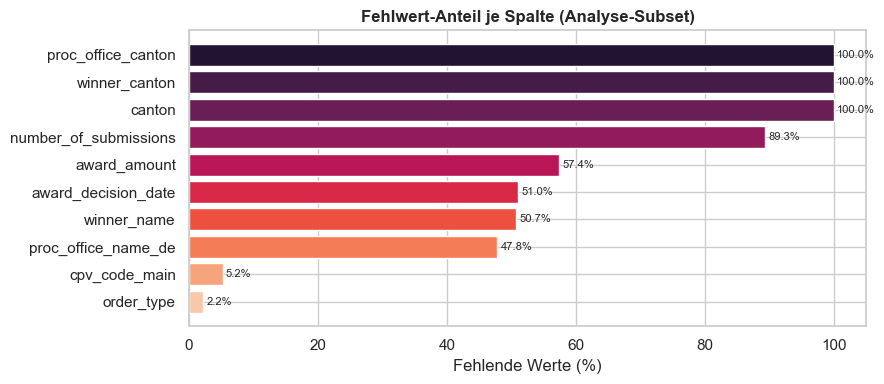

In [9]:
missing = df.isna().mean().sort_values(ascending=True) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(missing))))
ax.barh(missing.index, missing.values, color=sns.color_palette('rocket_r', len(missing)))
ax.set_xlabel('Fehlende Werte (%)')
ax.set_title('Fehlwert-Anteil je Spalte (Analyse-Subset)')
for i, v in enumerate(missing.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()


### 3) Zeitliche Verteilung
Wie viele Publikationen pro Jahr? Wie verteilen sich Ausschreibungen
(`OB01`) vs. Zuschlaege (`OB02`)?

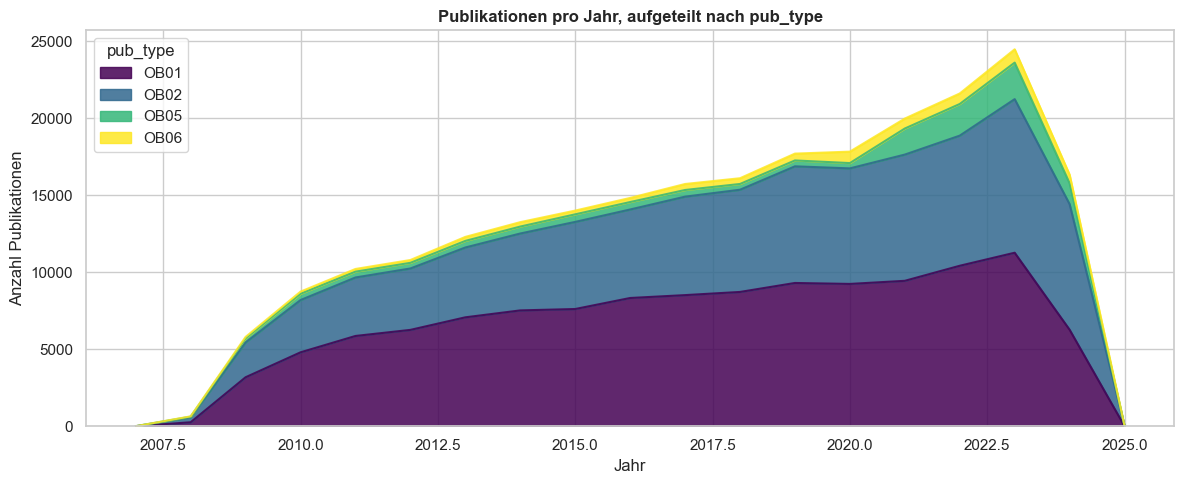

pub_type,OB01,OB02,OB05,OB06
year,,,,
2016,8333,5750,483,267
2017,8520,6397,432,390
2018,8726,6641,374,372
2019,9309,7578,382,444
2020,9247,7507,344,743
2021,9449,8201,1693,646
2022,10427,8454,2056,682
2023,11274,9979,2372,865
2024,6271,8156,1357,558


In [26]:
df['year'] = df['publication_date'].dt.year
jahresstat = df.groupby(['year', 'pub_type']).size().unstack(fill_value=0)
topt = df['pub_type'].value_counts().head(4).index.tolist()
jahresstat = jahresstat[topt]

fig, ax = plt.subplots(figsize=(12, 5))
jahresstat.plot.area(ax=ax, alpha=0.85, colormap='viridis')
ax.set_title('Publikationen pro Jahr, aufgeteilt nach pub_type')
ax.set_ylabel('Anzahl Publikationen'); ax.set_xlabel('Jahr')
ax.legend(title='pub_type', loc='upper left')
plt.tight_layout(); plt.show()

jahresstat.tail(10)


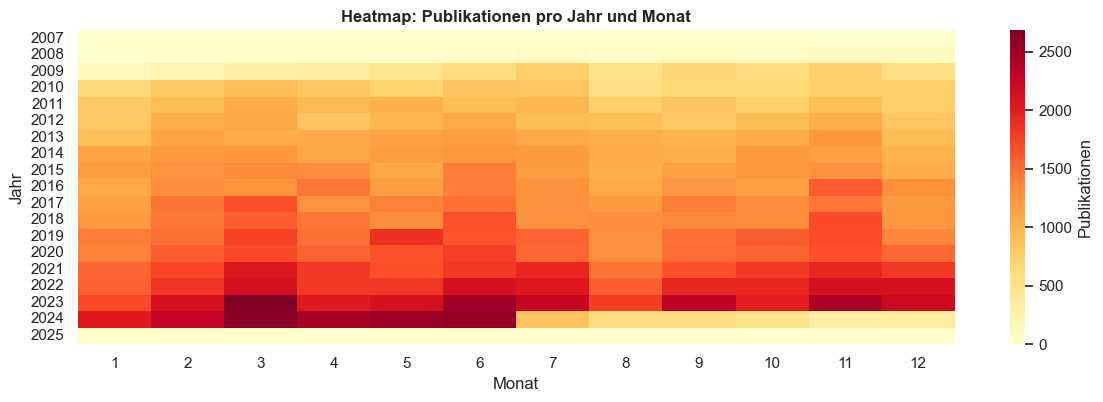

In [27]:
df['month'] = df['publication_date'].dt.month
pivot = (df.dropna(subset=['year', 'month'])
           .groupby(['year', 'month']).size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, max(4, 0.22 * len(pivot))))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Publikationen'}, ax=ax)
ax.set_title('Heatmap: Publikationen pro Jahr und Monat')
ax.set_xlabel('Monat'); ax.set_ylabel('Jahr')
plt.tight_layout(); plt.show()


### 4) Kategorische Verteilungen
`pub_type`, `process_type`, `order_type`, `project_type` geben den
fachlichen Kontext der Ausschreibungen.

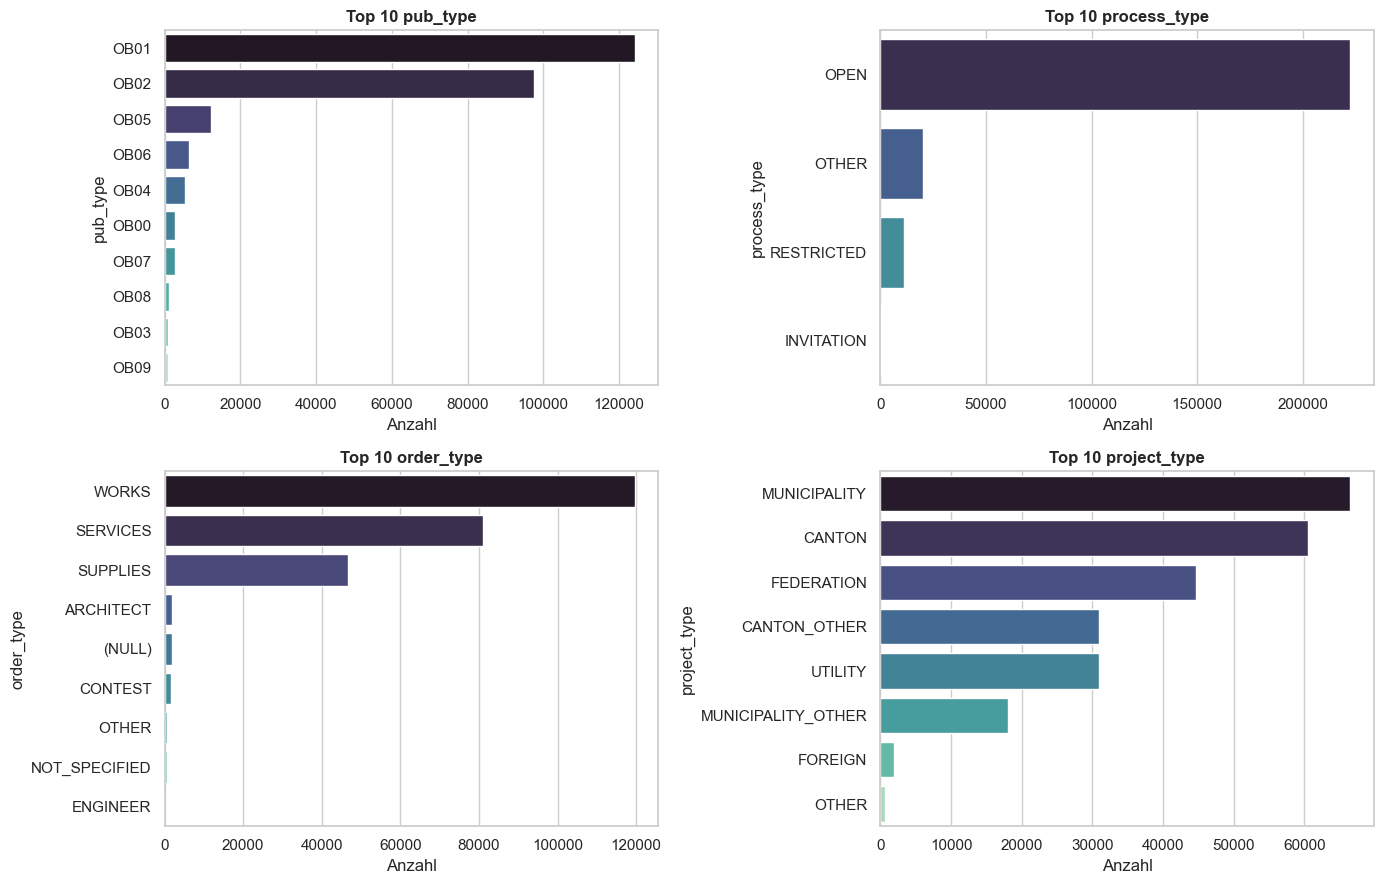

In [28]:
cat_cols = ['pub_type', 'process_type', 'order_type', 'project_type']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].fillna('(NULL)').value_counts().head(10)
    sns.barplot(x=vc.values, y=vc.index, ax=ax,
                palette='mako', hue=vc.index, legend=False)
    ax.set_title(f'Top 10 {col}')
    ax.set_xlabel('Anzahl')
plt.tight_layout(); plt.show()


### 5) Geografische Verteilung
Publikationen je Kanton (Beschaffungsstelle) und Gewinner-Kanton.
Beachte: `canton` ist haeufig NULL, wir nutzen daher
`proc_office_canton`.

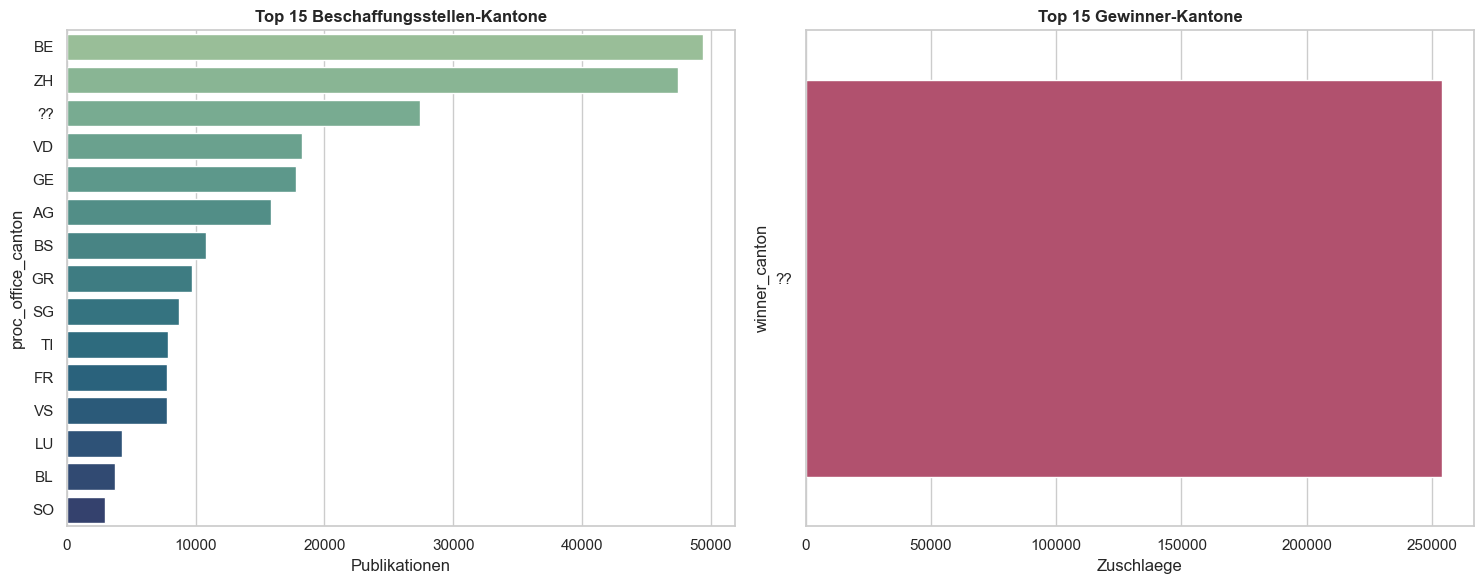

In [29]:
kanton = df['proc_office_canton'].fillna('??').value_counts()
winner = df['winner_canton'].fillna('??').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=kanton.head(15).values, y=kanton.head(15).index, ax=axes[0],
            palette='crest', hue=kanton.head(15).index, legend=False)
axes[0].set_title('Top 15 Beschaffungsstellen-Kantone'); axes[0].set_xlabel('Publikationen')

sns.barplot(x=winner.head(15).values, y=winner.head(15).index, ax=axes[1],
            palette='flare', hue=winner.head(15).index, legend=False)
axes[1].set_title('Top 15 Gewinner-Kantone'); axes[1].set_xlabel('Zuschlaege')
plt.tight_layout(); plt.show()


### 6) Zuschlagssummen (`award_amount`)
Preisverteilung klassisch in *Log-Skala*, da sehr schief.
Zusaetzlich: Perzentil-Tabelle und Boxplot pro Jahr (Median).

Zuschlaege mit Betrag: 85,861
count    8.586100e+04
mean     2.744882e+06
std      1.558652e+07
min      1.000000e-02
1%       1.593900e+02
10%      1.729290e+05
25%      3.318960e+05
50%      6.823893e+05
75%      1.705260e+06
90%      4.506780e+06
99%      3.285315e+07
max      1.879000e+09


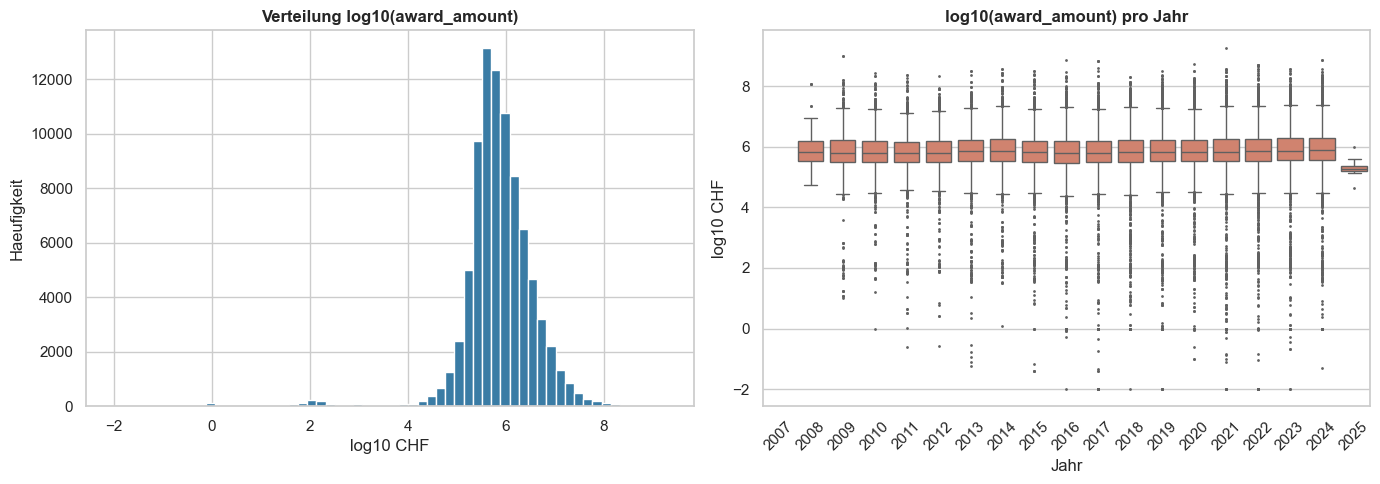

In [30]:
awd = df.loc[df['award_amount'].notna() & (df['award_amount'] > 0), 'award_amount']
print(f'Zuschlaege mit Betrag: {len(awd):,}')
perc = awd.describe(percentiles=[.01,.1,.25,.5,.75,.9,.99])
print(perc.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log10(awd), bins=60, color='#3a7ca5', edgecolor='white')
axes[0].set_title('Verteilung log10(award_amount)')
axes[0].set_xlabel('log10 CHF'); axes[0].set_ylabel('Haeufigkeit')

sns.boxplot(data=df.assign(log_amount=np.log10(df['award_amount'].where(df['award_amount']>0))),
            x='year', y='log_amount', ax=axes[1],
            color='#e07a5f', fliersize=1)
axes[1].set_title('log10(award_amount) pro Jahr')
axes[1].set_xlabel('Jahr'); axes[1].set_ylabel('log10 CHF')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


### 7) Top Gewinner & Beschaffungsstellen
Wer erhaelt am meisten Zuschlaege nach Anzahl und nach Summe?

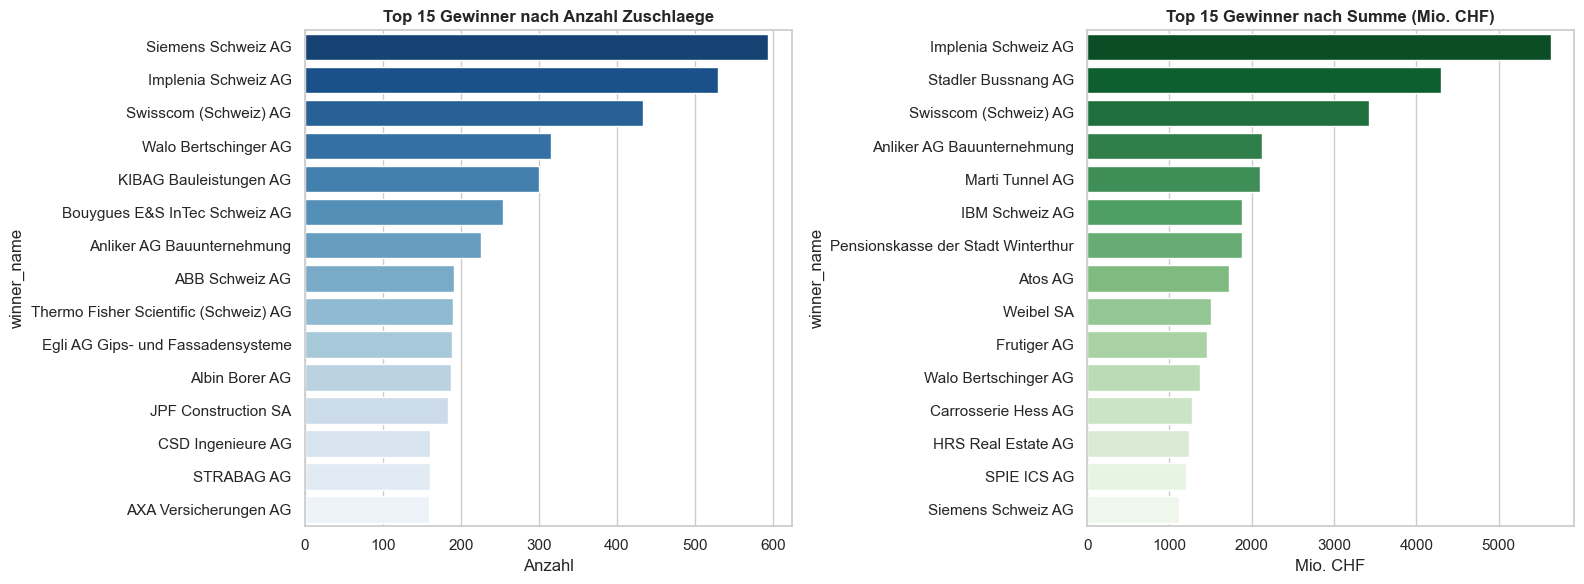

In [31]:
zuschlaege = df[df['pub_type'] == 'OB02']

anz_winner = (zuschlaege['winner_name'].dropna().value_counts().head(15))
summe_winner = (zuschlaege.dropna(subset=['winner_name','award_amount'])
                         .groupby('winner_name')['award_amount']
                         .sum().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=anz_winner.values, y=anz_winner.index, ax=axes[0],
            palette='Blues_r', hue=anz_winner.index, legend=False)
axes[0].set_title('Top 15 Gewinner nach Anzahl Zuschlaege'); axes[0].set_xlabel('Anzahl')

sns.barplot(x=summe_winner.values / 1e6, y=summe_winner.index, ax=axes[1],
            palette='Greens_r', hue=summe_winner.index, legend=False)
axes[1].set_title('Top 15 Gewinner nach Summe (Mio. CHF)'); axes[1].set_xlabel('Mio. CHF')
plt.tight_layout(); plt.show()


In [ ]:
proc = (df['proc_office_name_de'].dropna().value_counts().head(15))
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=proc.values, y=proc.index, ax=ax,
            palette='Purples_r', hue=proc.index, legend=False)
ax.set_title('Top 15 Beschaffungsstellen nach Anzahl Publikationen')
ax.set_xlabel('Publikationen')
plt.tight_layout(); plt.show()


### 8) Korrelation numerischer Features
Heatmap ueber `award_amount` (log), `number_of_submissions`, `lots_count`
und aus `publication_date` abgeleitete Features.

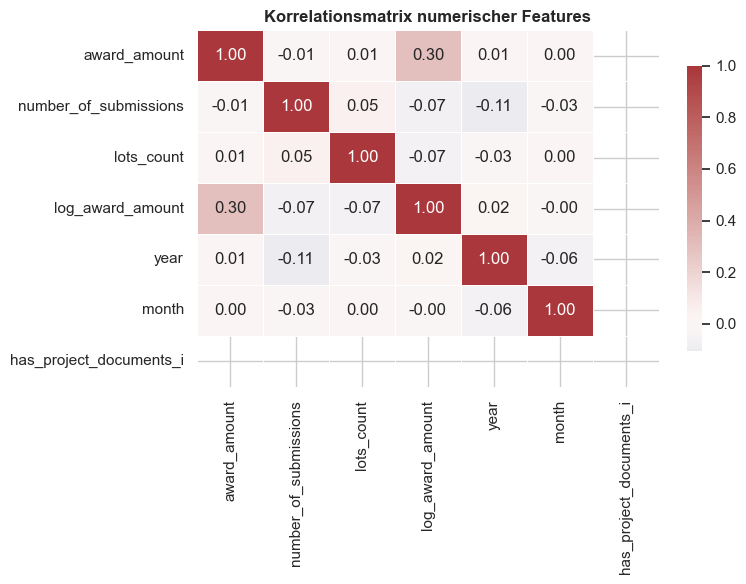

In [32]:
num = df[['award_amount', 'number_of_submissions', 'lots_count']].copy()
num['log_award_amount'] = np.log10(num['award_amount'].where(num['award_amount'] > 0))
num['year'] = df['publication_date'].dt.year
num['month'] = df['publication_date'].dt.month
num['has_project_documents_i'] = df['has_project_documents'].astype('float')

corr = num.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, fmt='.2f', ax=ax,
            linewidths=.5, cbar_kws={'shrink': .8})
ax.set_title('Korrelationsmatrix numerischer Features')
plt.tight_layout(); plt.show()


### 9) CPV-Top-Kategorien
Die fuehrende CPV-Hauptklassifikation (erste 2 Stellen)
gibt einen Beschaffungs-Branchen-Ueberblick.

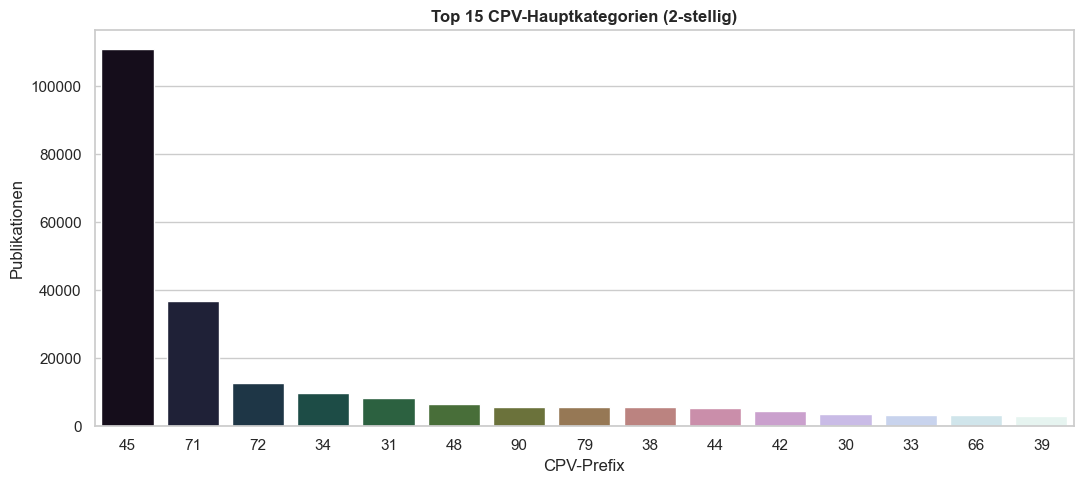

In [33]:
cpv = df['cpv_code_main'].dropna().astype(str).str[:2]
cpv_vc = cpv.value_counts().head(15)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=cpv_vc.index, y=cpv_vc.values, ax=ax,
            palette='cubehelix', hue=cpv_vc.index, legend=False)
ax.set_title('Top 15 CPV-Hauptkategorien (2-stellig)')
ax.set_xlabel('CPV-Prefix'); ax.set_ylabel('Publikationen')
plt.tight_layout(); plt.show()


### 10) Backup-Tabelle als CSV exportieren
Die in Supabase angelegte Backup-Tabelle `archive_deleted_backup_20260416`
enthaelt alle geloeschten Zeilen (inkl. `deletion_reason`, `deleted_at`).

Der folgende Block laedt sie paginiert und schreibt `archive_deleted_backup_20260416.csv`
ins Repo-Verzeichnis. Bei 20'694 Zeilen dauert das einige Sekunden.